### Sales Forecasting — Phase 4: Prophet + Full Model Comparison
### Rossmann Store Sales Dataset

Steps:
  1. Load Store 1 data + Phase 2/3 predictions
  2. Facebook Prophet with German public holidays
  3. Prophet component plots (trend, weekly, yearly, holidays)
  4. Full three-model comparison table — SARIMA, XGBoost, Prophet
  5. All-model forecast chart
  6. Business cost framing — inventory cost at each MAPE level

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/MyDrive/Sales_Forecasting")
print(os.listdir("."))

['store_1_daily_sales.csv', 'rossmann_clean.csv', 'data_cleaning_EDA.ipynb', 'arima_predictions.csv', 'ARIMA_SARIMA_baseline.ipynb', 'xgb_predictions.csv', 'XGBoost_Model.ipynb', 'outputs', 'data', 'model_comparison.ipynb']


In [3]:
!pip install prophet --quiet

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.facecolor": "white", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e5e5e5", "grid.linewidth": 0.6})

STORE_ID   = 1
TEST_WEEKS = 6
SEED       = 42

### LOAD DATA

In [6]:
print("Loading data...")
ts = pd.read_csv(f"store_{STORE_ID}_daily_sales.csv",
                 index_col=0, parse_dates=True).squeeze("columns")
ts.index.freq = "D"
ts.name = "Sales"

arima_preds = pd.read_csv("arima_predictions.csv", parse_dates=["Date"])
xgb_preds   = pd.read_csv("xgb_predictions.csv",   parse_dates=["Date"])

# Align test period across all models
test_dates = xgb_preds["Date"].values
y_test     = xgb_preds["Actual"].values

print("=" * 60)
print("PHASE 4 — PROPHET + FULL MODEL COMPARISON")
print("=" * 60)
print(f"Store        : {STORE_ID}")
print(f"Test period  : {pd.Timestamp(test_dates[0]).date()} → "
      f"{pd.Timestamp(test_dates[-1]).date()}")
print(f"Test days    : {len(test_dates)}")

Loading data...
PHASE 4 — PROPHET + FULL MODEL COMPARISON
Store        : 1
Test period  : 2015-06-20 → 2015-07-31
Test days    : 36


### PREPARE PROPHET DATA

In [7]:
#    Prophet expects a dataframe with columns: ds (date) and y (target)
#    We use log-transformed sales to stabilise variance


split_date = pd.Timestamp(test_dates[0]) - pd.Timedelta(days=1)

prophet_df = pd.DataFrame({
    "ds": ts.index,
    "y" : np.log1p(ts.values),    # log-transform for variance stabilisation
})

train_prophet = prophet_df[prophet_df["ds"] <= split_date]
test_prophet  = prophet_df[prophet_df["ds"] >  split_date]

print(f"\nProphet training rows : {len(train_prophet)}")
print(f"Prophet test rows     : {len(test_prophet)}")


Prophet training rows : 899
Prophet test rows     : 42


### TRAINING PROPHET

In [10]:
#    Key parameters:
#    - yearly_seasonality: captures annual sales cycles (Christmas etc.)
#    - weekly_seasonality: captures day-of-week pattern
#    - add_country_holidays: German public holidays (Rossmann is German)
#    - changepoint_prior_scale: controls trend flexibility

print("\n── Training Prophet ──────────────────────────────────")

prophet_model = Prophet(
    yearly_seasonality       = True,
    weekly_seasonality       = True,
    daily_seasonality        = False,    # too granular for daily data
    seasonality_mode         = "multiplicative",   # better for retail
    changepoint_prior_scale  = 0.05,    # how flexible the trend is
    seasonality_prior_scale  = 10.0,    # strength of seasonality
    holidays_prior_scale     = 10.0,    # strength of holiday effects
    interval_width           = 0.95,    # 95% uncertainty intervals
)

# Add German public holidays — Rossmann is a German drugstore chain
prophet_model.add_country_holidays(country_name="DE")

prophet_model.fit(train_prophet)
print("  Model trained successfully.")

# Forecast on test period
future       = prophet_model.make_future_dataframe(periods=len(test_prophet))
forecast_all = prophet_model.predict(future)
forecast_test = forecast_all[forecast_all["ds"] > split_date].copy()

# Align prophet predictions to match the dates available in y_test
# Convert test_dates to a Series of Timestamps for efficient filtering and alignment
test_dates_ts = pd.Series(pd.to_datetime(test_dates))
aligned_forecast_test = forecast_test[forecast_test['ds'].isin(test_dates_ts)].sort_values(by='ds').copy()

# Back-transform from log scale
prophet_pred = np.expm1(aligned_forecast_test["yhat"].values)
prophet_lower = np.expm1(aligned_forecast_test["yhat_lower"].values)
prophet_upper = np.expm1(aligned_forecast_test["yhat_upper"].values)

# ── Evaluation ────────────────────────────────────────────────────────────
def evaluate(actual, predicted, label):
    actual    = np.array(actual)
    predicted = np.array(predicted)
    mask      = actual > 0
    mape = np.mean(np.abs((actual[mask]-predicted[mask])/actual[mask])) * 100
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    print(f"  {label:<28} MAPE={mape:.2f}%  "
          f"RMSE=€{rmse:,.0f}  MAE=€{mae:,.0f}")
    return {"Model": label, "MAPE": round(mape,2),
            "RMSE": round(rmse,0), "MAE": round(mae,0)}

print("\nProphet evaluation:")
prophet_result = evaluate(y_test, prophet_pred, "Prophet + DE holidays")


── Training Prophet ──────────────────────────────────
  Model trained successfully.

Prophet evaluation:
  Prophet + DE holidays        MAPE=14.51%  RMSE=€777  MAE=€654


### PROPHET COMPONENT PLOTS

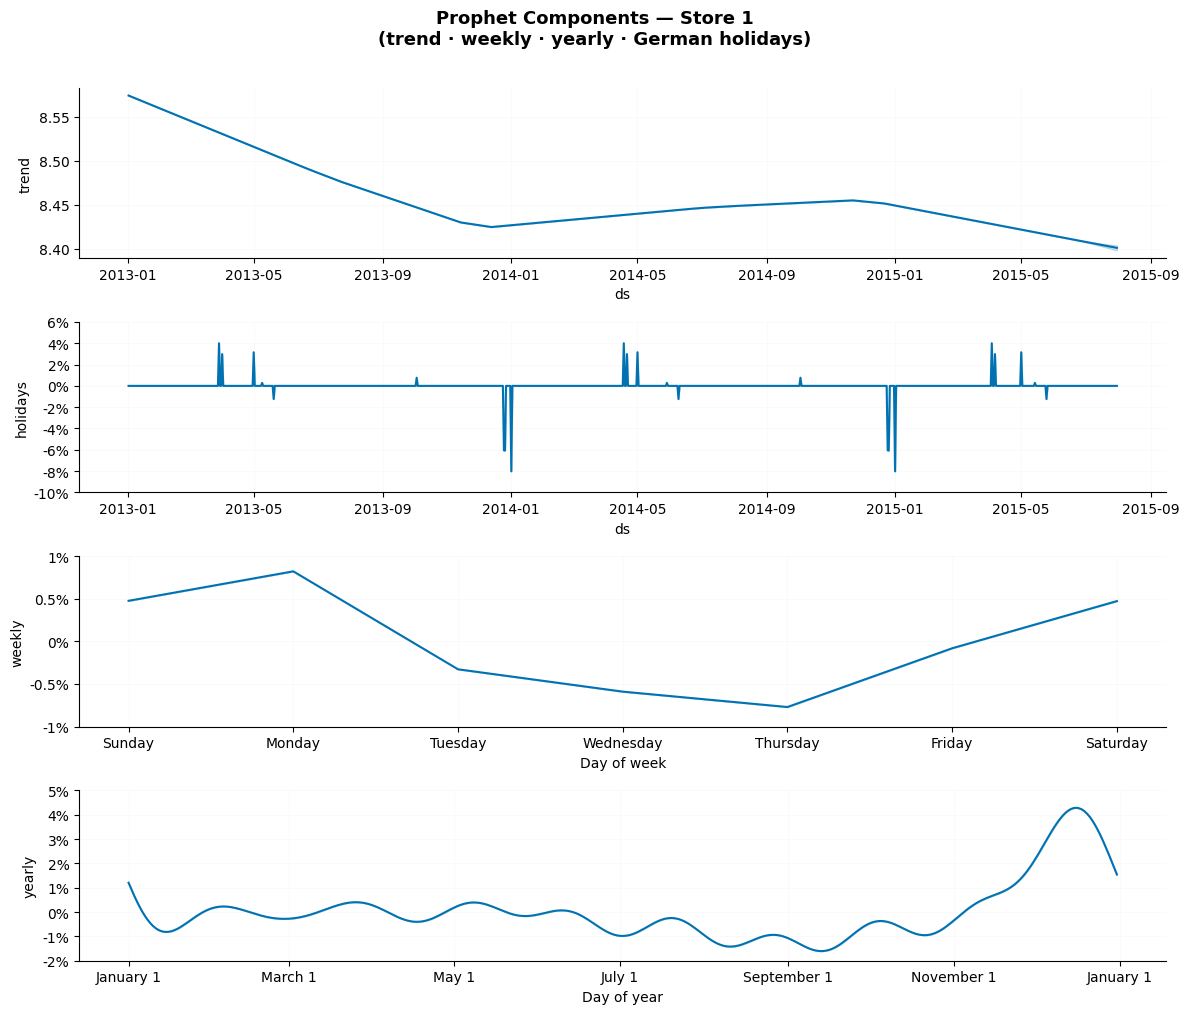


Saved: phase4_prophet_components.png


In [11]:
#    The most readable time series decomposition in the project:
#    trend, weekly seasonality, yearly seasonality, holiday effects
# ════════════════════════════════════════════════════════════════════════════

fig = prophet_model.plot_components(forecast_all)
fig.set_size_inches(12, 10)
fig.suptitle("Prophet Components — Store 1\n"
             "(trend · weekly · yearly · German holidays)",
             fontweight="bold", fontsize=13, y=1.01)
for ax in fig.get_axes():
    ax.set_facecolor("white")
    ax.grid(True, color="#e5e5e5", linewidth=0.6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("phase4_prophet_components.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: phase4_prophet_components.png")

### PROPHET FORECAST WITH UNCERTAINTY INTERVALS

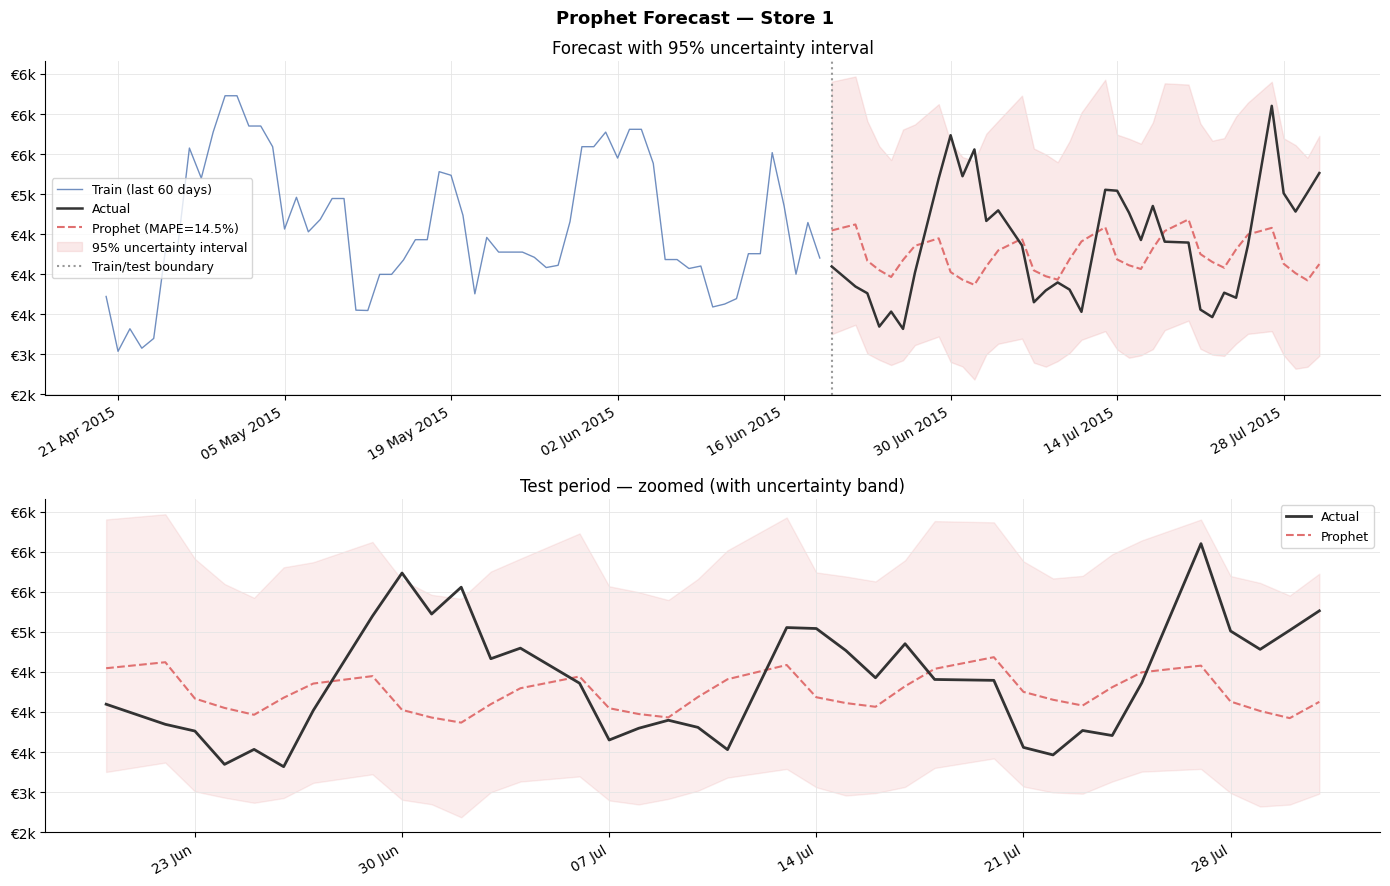

In [12]:
# Full forecast context (last 60 train days + test)
context_start = split_date - pd.Timedelta(days=60)
forecast_ctx  = forecast_all[forecast_all["ds"] >= context_start]
ts_ctx        = ts[ts.index >= context_start]

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle(f"Prophet Forecast — Store {STORE_ID}",
             fontweight="bold", fontsize=13)

# Panel 1: Context + forecast with uncertainty band
ax = axes[0]
train_ctx = ts_ctx[ts_ctx.index <= split_date]
ax.plot(train_ctx.index, train_ctx.values,
        color="#4C72B0", linewidth=1, alpha=0.8,
        label="Train (last 60 days)")
ax.plot(pd.to_datetime(test_dates), y_test,
        color="#333", linewidth=1.8, label="Actual", zorder=5)
ax.plot(pd.to_datetime(test_dates), prophet_pred,
        color="#E07070", linewidth=1.5, linestyle="--",
        label=f"Prophet (MAPE={prophet_result['MAPE']:.1f}%)")
ax.fill_between(pd.to_datetime(test_dates),
                prophet_lower, prophet_upper,
                alpha=0.15, color="#E07070",
                label="95% uncertainty interval")
ax.axvline(pd.Timestamp(test_dates[0]), color="#999",
           linestyle=":", linewidth=1.5, label="Train/test boundary")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.set_title("Forecast with 95% uncertainty interval")
ax.legend(fontsize=9)

# Panel 2: Predicted vs actual — test period zoomed
ax2 = axes[1]
ax2.plot(pd.to_datetime(test_dates), y_test,
         color="#333", linewidth=2, label="Actual", zorder=5)
ax2.plot(pd.to_datetime(test_dates), prophet_pred,
         color="#E07070", linewidth=1.5, linestyle="--", label="Prophet")
ax2.fill_between(pd.to_datetime(test_dates),
                 prophet_lower, prophet_upper,
                 alpha=0.12, color="#E07070")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax2.set_title("Test period — zoomed (with uncertainty band)")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("phase4_prophet_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

### FULL THREE-MODEL COMPARISON TABLE

In [15]:
# Get SARIMA best result from arima_predictions

# Convert test_dates to a Series of Timestamps for efficient filtering
test_dates_ts_for_arima = pd.Series(pd.to_datetime(test_dates))

# Filter arima_preds to align with test_dates
aligned_arima_preds = arima_preds[arima_preds['Date'].isin(test_dates_ts_for_arima)].sort_values(by='Date').copy()

arima_actual = aligned_arima_preds["Actual"].values
sarima_pred  = aligned_arima_preds["AutoSARIMA_pred"].values \
    if "AutoSARIMA_pred" in aligned_arima_preds.columns \
    else aligned_arima_preds["SARIMA_pred"].values

# Get XGBoost result
xgb_pred = xgb_preds["XGB_pred"].values

print("\n" + "=" * 65)
print("FULL THREE-MODEL COMPARISON")
print("=" * 65)

all_results = []
all_results.append(evaluate(arima_actual, sarima_pred,   "SARIMA (seasonal)"))
all_results.append(evaluate(y_test,       xgb_pred,      "XGBoost (tuned)"))
all_results.append(evaluate(y_test,       prophet_pred,  "Prophet + DE holidays"))

comp_df = pd.DataFrame(all_results).sort_values("MAPE")

print(f"\n{'='*65}")
print("COMPARISON TABLE  (sorted by MAPE — lower is better)")
print(f"{'='*65}")
print(comp_df.to_string(index=False))

best_model = comp_df.iloc[0]["Model"]
best_mape  = comp_df.iloc[0]["MAPE"]
print(f"\n✓ Best model: {best_model}  MAPE={best_mape:.2f}%")


FULL THREE-MODEL COMPARISON
  SARIMA (seasonal)            MAPE=16.10%  RMSE=€771  MAE=€652
  XGBoost (tuned)              MAPE=6.06%  RMSE=€332  MAE=€267
  Prophet + DE holidays        MAPE=14.51%  RMSE=€777  MAE=€654

COMPARISON TABLE  (sorted by MAPE — lower is better)
                Model  MAPE  RMSE   MAE
      XGBoost (tuned)  6.06 332.0 267.0
Prophet + DE holidays 14.51 777.0 654.0
    SARIMA (seasonal) 16.10 771.0 652.0

✓ Best model: XGBoost (tuned)  MAPE=6.06%


### ALL THREE FORECASTS ON ONE CHART

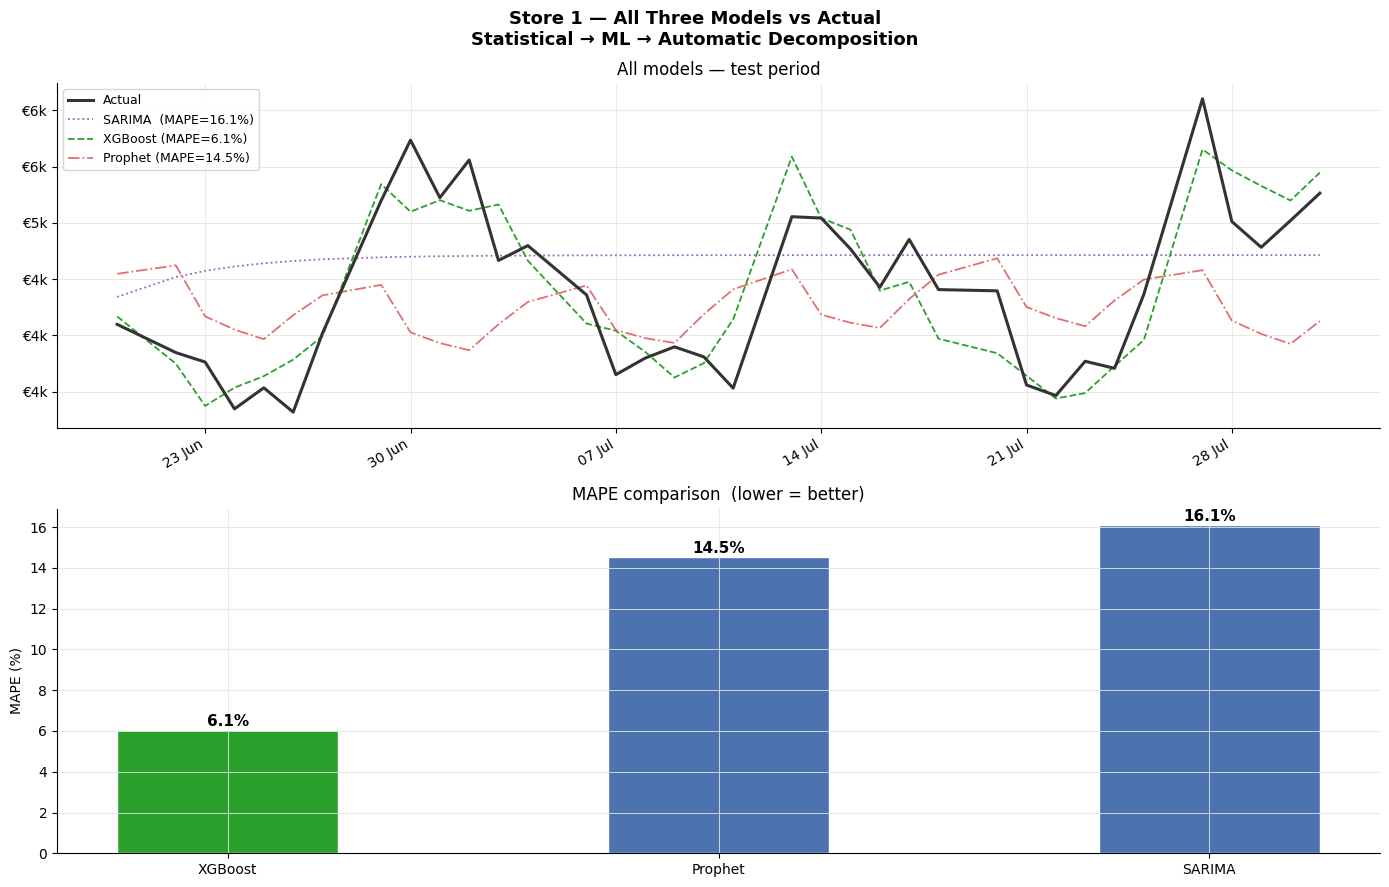

In [16]:
MODEL_COLORS = {
    "SARIMA"  : "#9467BD",
    "XGBoost" : "#2ca02c",
    "Prophet" : "#E07070",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle(f"Store {STORE_ID} — All Three Models vs Actual\n"
             "Statistical → ML → Automatic Decomposition",
             fontweight="bold", fontsize=13)

# Panel 1: All forecasts
ax = axes[0]
ax.plot(pd.to_datetime(test_dates), y_test,
        color="#333", linewidth=2.2, label="Actual", zorder=5)
ax.plot(pd.to_datetime(test_dates), sarima_pred,
        color="#9467BD", linewidth=1.3, linestyle=":",
        label=f"SARIMA  (MAPE={comp_df[comp_df['Model'].str.contains('SARIMA')]['MAPE'].values[0]:.1f}%)")
ax.plot(pd.to_datetime(test_dates), xgb_pred,
        color="#2ca02c", linewidth=1.3, linestyle="--",
        label=f"XGBoost (MAPE={comp_df[comp_df['Model'].str.contains('XGBoost')]['MAPE'].values[0]:.1f}%)")
ax.plot(pd.to_datetime(test_dates), prophet_pred,
        color="#E07070", linewidth=1.3, linestyle="-.",
        label=f"Prophet (MAPE={prophet_result['MAPE']:.1f}%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"€{x/1000:.0f}k"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax.set_title("All models — test period")
ax.legend(fontsize=9, loc="upper left")

# Panel 2: MAPE by model — summary bar
ax2 = axes[1]
mape_vals  = comp_df["MAPE"].values
mape_names = [m.split(" ")[0] for m in comp_df["Model"].values]
bar_colors = ["#2ca02c" if i == 0 else "#4C72B0"
              for i in range(len(mape_vals))]
bars = ax2.bar(mape_names, mape_vals, color=bar_colors, width=0.45, edgecolor="white")
ax2.set_ylabel("MAPE (%)")
ax2.set_title("MAPE comparison  (lower = better)")
for bar, v in zip(bars, mape_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("phase4_all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### BUSINESS COST FRAMING

In [17]:
#    Translate MAPE into inventory cost
#    A 10% MAPE → ~10% overstock OR understock on average
#    At average daily sales of €X per store, that's €Y wasted per day
# ════════════════════════════════════════════════════════════════════════════

AVG_DAILY_SALES   = float(ts.mean())
OVERSTOCK_COST    = 0.20   # 20% of overstocked value is wasted (storage, spoilage)
UNDERSTOCK_COST   = 0.30   # 30% of understocked value is lost margin

print(f"\n{'='*65}")
print("BUSINESS COST FRAMING")
print(f"{'='*65}")
print(f"Average daily sales (Store {STORE_ID}) : €{AVG_DAILY_SALES:,.0f}")
print(f"Overstock cost assumption              : {OVERSTOCK_COST*100:.0f}% of excess inventory")
print(f"Understock cost assumption             : {UNDERSTOCK_COST*100:.0f}% of missed sales\n")

biz_rows = []
for _, row in comp_df.iterrows():
    mape        = row["MAPE"] / 100
    daily_error = AVG_DAILY_SALES * mape
    # Assume errors split 60% overstock, 40% understock
    overstock_daily = daily_error * 0.6 * OVERSTOCK_COST
    understock_daily = daily_error * 0.4 * UNDERSTOCK_COST
    total_daily_cost = overstock_daily + understock_daily
    annual_cost      = total_daily_cost * 365

    biz_rows.append({
        "Model"           : row["Model"],
        "MAPE"            : f"{row['MAPE']:.1f}%",
        "Daily error €"   : f"€{daily_error:,.0f}",
        "Daily cost €"    : f"€{total_daily_cost:,.0f}",
        "Annual cost €"   : f"€{annual_cost:,.0f}",
    })
    print(f"  {row['Model']}")
    print(f"    MAPE            : {row['MAPE']:.1f}%")
    print(f"    Avg daily error : €{daily_error:,.0f}")
    print(f"    Est. daily cost : €{total_daily_cost:,.0f}")
    print(f"    Est. annual cost: €{annual_cost:,.0f}\n")

biz_df = pd.DataFrame(biz_rows)


BUSINESS COST FRAMING
Average daily sales (Store 1) : €4,792
Overstock cost assumption              : 20% of excess inventory
Understock cost assumption             : 30% of missed sales

  XGBoost (tuned)
    MAPE            : 6.1%
    Avg daily error : €290
    Est. daily cost : €70
    Est. annual cost: €25,439

  Prophet + DE holidays
    MAPE            : 14.5%
    Avg daily error : €695
    Est. daily cost : €167
    Est. annual cost: €60,911

  SARIMA (seasonal)
    MAPE            : 16.1%
    Avg daily error : €772
    Est. daily cost : €185
    Est. annual cost: €67,586



### Business cost bar chart

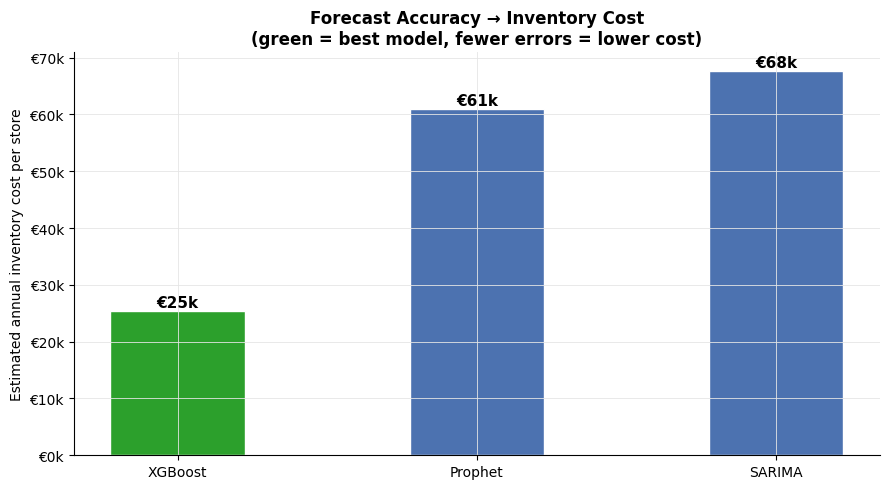

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
annual_costs = [float(r["Annual cost €"].replace("€","").replace(",",""))
                for _, r in biz_df.iterrows()]
model_names  = [r["Model"].split(" ")[0] for _, r in biz_df.iterrows()]
bar_cols     = ["#2ca02c"] + ["#4C72B0"] * (len(annual_costs)-1)

bars = ax.bar(model_names, annual_costs, color=bar_cols,
              width=0.45, edgecolor="white")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"€{x/1000:.0f}k"))
ax.set_ylabel("Estimated annual inventory cost per store")
ax.set_title("Forecast Accuracy → Inventory Cost\n"
             "(green = best model, fewer errors = lower cost)",
             fontweight="bold")
for bar, v in zip(bars, annual_costs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(annual_costs)*0.01,
            f"€{v/1000:.0f}k", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("phase4_business_cost.png", dpi=150, bbox_inches="tight")
plt.show()